# **NOTEBOOK 2 : Diverses fonctions de fits et de plots pour analyser les résultats**

## Convertir toutes les données .h5 en .txt

La fonction ``convert_all_odmr_and_scalar`` change toutes les données ``odmr.h5`` et ``scalarData.h5`` (qui se trouvent dans les fichiers de données de QZabre après une mesure).  
Il faut bien spécifier le chemin du dossier contenant tous les fichiers de mesures.  
Il faut bien définir le directoir de travail où se trouve les helpers.py et autre fichiers de code .py contenant les fonctions.  
Les fichiers textes sont ajoutés dans chacun des dossiers de mesure.


In [1]:
from pathlib import Path
data_directory = Path(r"C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM\Datas2")
working_directory = Path(r"C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM")

from helpers import convert_all_odmr_and_scalar
convert_all_odmr_and_scalar(data_directory, show_skip=False, date_min="2025-07-01") #ici, date_min ne converti pas les fichiers anterieurs au 01/07/2026, on peut mettre None sinon

Parcours de C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM\Datas2 ...


Terminé (fichiers .h5 convertis en .txt)


## Creation de la liste des dates de mesures

Construction automatique d'une liste de dates à partir des noms des fichiers de données.  
On peut manuellement ajouter des dates à supprimer de la liste (mesures ratées, etc).

In [2]:
from helpers import build_date_list

#Fonction qui construit automatiquement une liste de toutes les dates dans le fichier de données
all_dates = build_date_list(data_directory)

dates_à_supprimer = {
    "2025-11-17-18-36-10", #bande verticale
    "2025-11-18-02-03-46", #scan raté, seulement quelques lignes
    "2025-12-03-16-41-04", #celle rotation 90 trop chiant à changer

    #tous les autres scans raté (quelques lignes, où vraiment illisibles / incohérents):
    "2025-11-04-19-11-27", "2025-11-06-18-19-44", "2025-11-07-18-38-38", "2025-11-08-08-46-50", "2025-11-08-18-50-31", "2025-11-09-15-32-27", "2025-11-09-23-24-49", "2025-11-10-09-51-47",
    "2025-11-10-12-15-04", "2025-11-11-18-31-55", "2025-11-12-21-34-31", "2025-11-20-17-01-40","2025-12-12-11-52-52", "2025-12-15-01-22-30"
}

all_dates = [d for d in all_dates if d not in dates_à_supprimer]

print("[indices] Dates :")
for i, d in enumerate(all_dates):
    print(f"[{i}] {d}")

[indices] Dates :
[0] 2025-06-20-18-43-28
[1] 2025-07-20-16-46-16
[2] 2025-10-28-08-31-40
[3] 2025-10-28-14-57-09
[4] 2025-10-30-12-57-30
[5] 2025-10-31-08-28-12
[6] 2025-10-31-11-48-09
[7] 2025-10-31-18-26-22
[8] 2025-11-01-19-06-18
[9] 2025-11-02-09-26-37
[10] 2025-11-11-08-25-09
[11] 2025-11-12-13-06-46
[12] 2025-11-13-13-50-33
[13] 2025-11-13-22-20-57
[14] 2025-11-14-22-59-02
[15] 2025-11-15-20-13-45
[16] 2025-11-16-23-41-29
[17] 2025-11-18-12-47-24
[18] 2025-11-19-15-47-12
[19] 2025-11-21-17-50-24
[20] 2025-11-22-00-14-27
[21] 2025-11-22-09-40-00
[22] 2025-11-23-00-27-18
[23] 2025-11-23-18-37-53
[24] 2025-11-24-13-06-13
[25] 2025-11-25-00-58-29
[26] 2025-11-25-19-49-32
[27] 2025-11-26-14-16-10
[28] 2025-11-27-14-12-52
[29] 2025-11-28-12-45-13
[30] 2025-11-29-16-05-00
[31] 2025-11-30-04-07-17
[32] 2025-11-30-13-12-29
[33] 2025-11-30-21-38-20
[34] 2025-12-01-13-42-23
[35] 2025-12-01-22-11-42
[36] 2025-12-02-13-07-59
[37] 2025-12-03-02-08-52
[38] 2025-12-04-13-29-57
[39] 2025-12-05-1

On peut ensuite choisir en détail quelles dates l'on veut séléctionner. Ici on ne sélectionne que les 10 premières dates.

In [3]:
%load_ext autoreload
%autoreload 2

date = "2025-07-20-16-46-16"
dates = all_dates[:10]              #[-13:] #[-9:-5]


Léger pré traitement des données (fenêtre de lissage, normalisation par la médiane), et désactivation éventuelle des fréquences (utiles pour débugger les fits, mais à laisser en "frequences_odmr" maintenant).  

In [4]:
#pour faire des plots avec axe x en fonction des fréquences, utile pour débug si on a des problèmes avec les fréquences
FREQ_MODE  = "frequences_odmr"          # "k_linear" | "frequences_odmr"

# Pré-traitement (normalisation et lissage)
NORMALIZE  = True     # True => normalise counts par la médiane du sweep
SMOOTH_WIN = 3        # fenêtre de lissage (entier impair >= 3) ; 0 pour désactiver

# Performance
DOWNCAST_INT = True   # essaie de convertir counts en int32 pour économiser de la mémoire

## Chargement des données

Se fait via:
- ``load_df1`` pour le ``odmr.txt`` (dataset 1 contenant les spectres odmr complet, sur toute la surface 2D).  
- ``load_df2`` pour le ``scalarData.txt`` (dataset 2 contenant TOUS les scans 2D que l'on voit sur l'écran QZabre (afm:height, afm:phase, etc)).  

La fonction ``concatenate_data_df1`` permet de concatener des datasets. Par exemple, deux mesures 2D que l'on souhaite coller en une seule grande mesure.  
(la fonction est assez embêtante à utiliser, à cause de divers problèmes d'indices mal optimisés dans les set de données de QZabre, il est préférable de ne pas essayer de concaténer différentes mesures)

Note : les deux datasets n'ont pas les mêmes indices, les fonctions de plots prennent ça en compte et mettent tout dans la même convention.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#print("pandas:", pd.__version__)

In [6]:
# CHARGEMENTS DES PARAMETRES EXPERIMENTAUX
import json
#json contenant tous les paramètres de l'experience
meta_path = data_directory / f"{date}-odmr_hardware" / "imageMeta.json"
with open(meta_path, "r") as f:
    param_exp = json.load(f)


# CHARGEMENT DES DATA_1 --> SPECTROGRAMMES

os.chdir(working_directory)
from helpers import load_df1, concatener_data_df1

base = data_directory / f"{date}-odmr_hardware" / "seq0" / "eval"
os.chdir(base)
TXT_PATH = "odmr.txt"  # "integratedCounts.txt"
    
df = load_df1(TXT_PATH, DOWNCAST_INT, infos=True)

# example de concatenation de données
if date == "2025-11-16-23-41-29":
    band_folder = data_directory / "2025-11-17-18-36-10-odmr_hardware" / "seq0" / "eval"
    band_file = band_folder / "odmr.txt"
    df_band = load_df1(band_file, DOWNCAST_INT=True)
    df = concatener_data_df1(df, df_band, infos=False)

df.head()


Dimensions: i=110, j=110, k=100
Index(['i', 'j', 'k', 'frequency', 'sig', 'contrast'], dtype='object')


,i,j,k,frequency,sig,contrast
0,0,0,0,2.699575e+09,12272,0.987319
1,0,0,1,2.701575e+09,12159,0.978228
2,0,0,2,2.703575e+09,12052,0.969620
3,0,0,3,2.705575e+09,12198,0.981366
4,0,0,4,2.707575e+09,12244,0.985067


Ici, ``sig`` fait référence au counts bruts du signal

In [7]:
# CHARGEMENT DES DATA_2 --> MESURES QZABRE (afm:height, afm:phase, odmr:mTesla0, etc)

os.chdir(working_directory)
from helpers import load_df2, concatener_data_df2

base = Path(r"C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM\Datas2") / f"{date}-odmr_hardware"
os.chdir(base)
SCALAR_PATH = "scalarData.txt"

df2 = load_df2(SCALAR_PATH, infos=True)

if date == "2025-11-16-23-41-29":
    band_folder = data_directory / "2025-11-17-18-36-10-odmr_hardware"
    band_file = band_folder / "scalarData.txt"
    df_band = load_df2(band_file)
    df2 = concatener_data_df2(df2, df_band, infos=False)

#print(df2["afm:height"].keys())
df2.head()

Dimensions: i=110, j=110
Index(['i', 'j', 'odmr:mTesla0', 'odmr:Gauss0', 'odmr:resonanceFrequency0',
       'odmr:resonanceFrequency_err0', 'odmr:FWHM0', 'odmr:FWHM_err0',
       'odmr:contrast0', 'odmr:contrast_err0', 'odmr:sensitivity0',
       'odmr:integrationTime', 'odmr:intensity', 'afm:height', 'afm:amplitude',
       'afm:phase', 'afm:frequency', 'afm:scanHeight', 'afm:refPointX',
       'afm:refPointY', 'afm:refPointZ', 'afm:zDist', 'afm:success',
       'moke:difference', 'moke:A', 'moke:B', 'moke:arctan((A-diff)/A)',
       'moke:difference/(A+B)'],
      dtype='object')


,i,j,odmr:mTesla0,odmr:Gauss0,odmr:resonanceFrequency0,odmr:resonanceFrequency_err0,odmr:FWHM0,odmr:FWHM_err0,odmr:contrast0,odmr:contrast_err0,...,afm:refPointX,afm:refPointY,afm:refPointZ,afm:zDist,afm:success,moke:difference,moke:A,moke:B,moke:arctan((A-diff)/A),moke:difference/(A+B)
0,0,0,2.479083,24.790827,2.800524e+09,1.002687e+06,3.483033e+07,2.787853e+06,0.128619,0.005013,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0
1,0,1,5.745540,57.455398,2.708982e+09,1.655074e+06,5.905917e+07,4.870061e+06,0.065167,0.003678,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0
2,0,2,5.793906,57.939062,2.707626e+09,1.531914e+06,5.895501e+07,4.505199e+06,0.071523,0.003743,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0
3,0,3,6.580376,65.803760,2.685585e+09,1.319314e+06,6.121423e+07,3.901606e+06,0.077757,0.003377,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0
4,0,4,6.729541,67.295410,2.681405e+09,8.425056e+05,4.557827e+07,2.430291e+06,0.090797,0.003370,...,NaN,NaN,NaN,1.500000e-07,1.0,0.0,0.0,0.0,0.0,0.0


## PLOT carte contrast et argmin des spectrogrammes

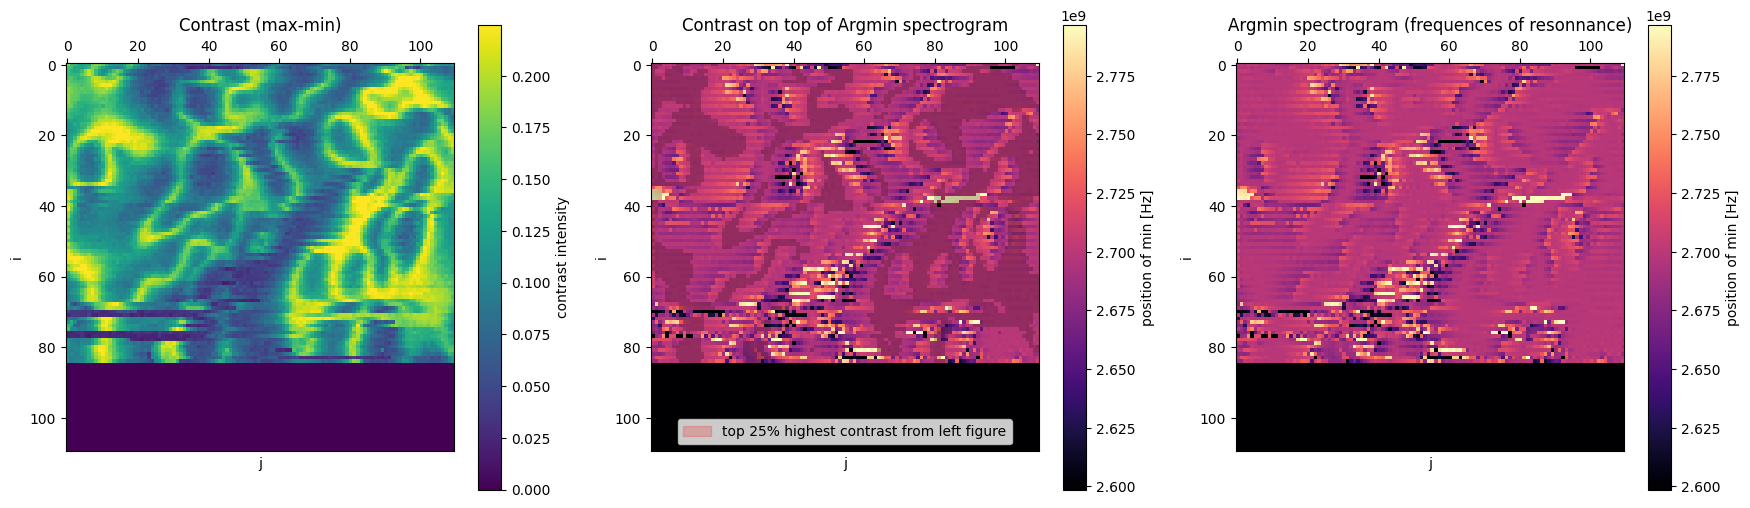

In [8]:
from helpers import plot_contrast_argmin
#plot_QZabre, plot_on_ax, build_x_axis, maybe_normalize, maybe_smooth, _add_roi_box, concatener_data_df2, plot_contrast_argmin, plot_QZabre_surf, plot_QZabre_surf_old, overlay_max_band

plot_contrast_argmin(df, NORMALIZE, SMOOTH_WIN,
              30,30, half=100, use_processed=True, grid=False, panel_size=(5.9,5.4),
              #pdf_path="map.pdf",   # uncomment pour sauvegarder automatiquement un pdf
              )

## FITS

In [9]:
os.chdir(working_directory)
from fits import plot_fits_on_spectrograms, plot_init_guesses
from helpers import compute_B_components, plot_B1_B2_DeltaB_projectionNV,  plot_contrast_DeltaB_projectionNV 

Avant d'effectuer les fits, des guess initiaux sont effectués. En effet, la performance des fits est grandement améliorée si on a des guess initiaux plus ou moins correct.  
Trois méthodes de guess sont présentées.  
Globalement la meilleure est ``init symetric``, car bien qu'elle ne soie pas aussi précise que ``MAP`` (maximum à posteriori), ce guess symetric est très rapide à initialiser et permet en pratique de donner des fits corrects.

Succès optimisation : True | CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH

Paramètres (MAP vs prior):
   B: MAP= 1.00828, prior_mu= 1.00828, prior_sigma= 0.302483
  A1: MAP= 0.0544719, prior_mu= 0.0508405, prior_sigma= 0.8
  A2: MAP= 0.0363146, prior_mu= 0.0508405, prior_sigma= 0.8
 nu1: MAP= 2.98151e+09, prior_mu= 2.97351e+09, prior_sigma= 3.96e+07
 nu2: MAP= 3.02951e+09, prior_mu= 2.98951e+09, prior_sigma= 3.96e+07
  g1: MAP= 1e+07, prior_mu= 1e+07, prior_sigma= 1e+07
  g2: MAP= 1.2e+07, prior_mu= 1e+07, prior_sigma= 1e+07


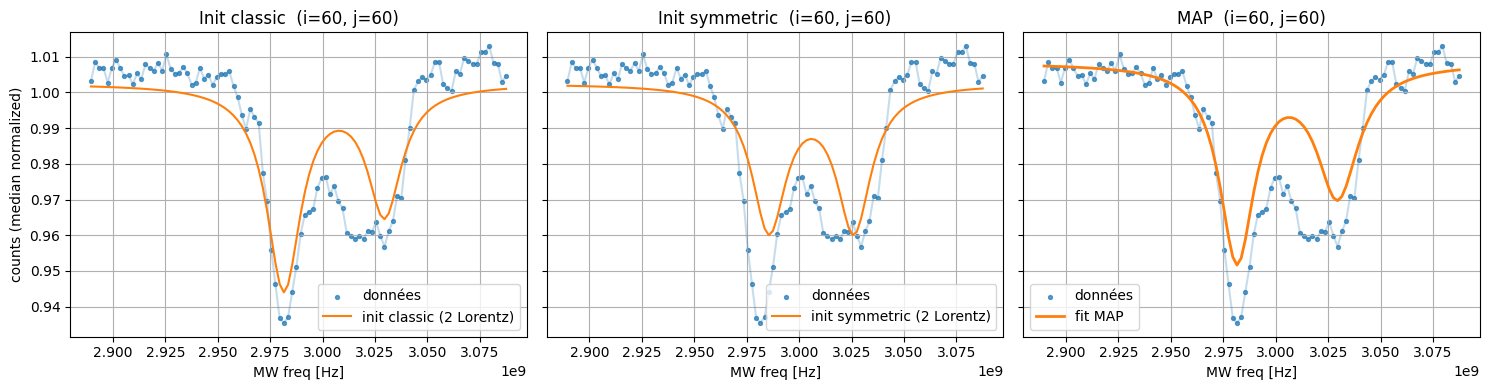

In [10]:
id_i = 60
id_j =60

plot_init_guesses(
    df,
    indice_i=id_i,
    indice_j=id_j,
    FREQ_MODE=FREQ_MODE,
    NORMALIZE=NORMALIZE,
    SMOOTH_WIN=SMOOTH_WIN,
    T=1.0,
    infos=True,
    D=2.87e9,   
    keep_if_global_min=False,
    b1_to_zero=True,
    oldversion=False,
)

Fits via la fonction ``plot_fits_on_spectrograms``.  
``half_big`` est défini pour le plot avec la fonction ``plot_contrast_argmin``.  
``half_small`` est le paramètre important qui délimite jusqu'à où sur le scan 2D les données vont être fittées. Cette variable permet d'analyser en détail les différents spectrogrammes et leurs fits (par exemple, en se concentrant sur une très petite fenêtre et avec SHOW_PLOT=True).  
Note que pour SHOW_PLOT=True, au delà de half_small=11 le temps de calcul devient exponentiellement long (à cause de la figure). Ainsi, il est recommandé d'afficher les fits seulements pour des petites fenêtres, et une fois que tout semble fonctionner, lancer les fits sur l'ensemble des spectrogrammes de la surface 2D scannée (avec un grand half_small et show_plot=False)

dimentions :  110, 110, 100


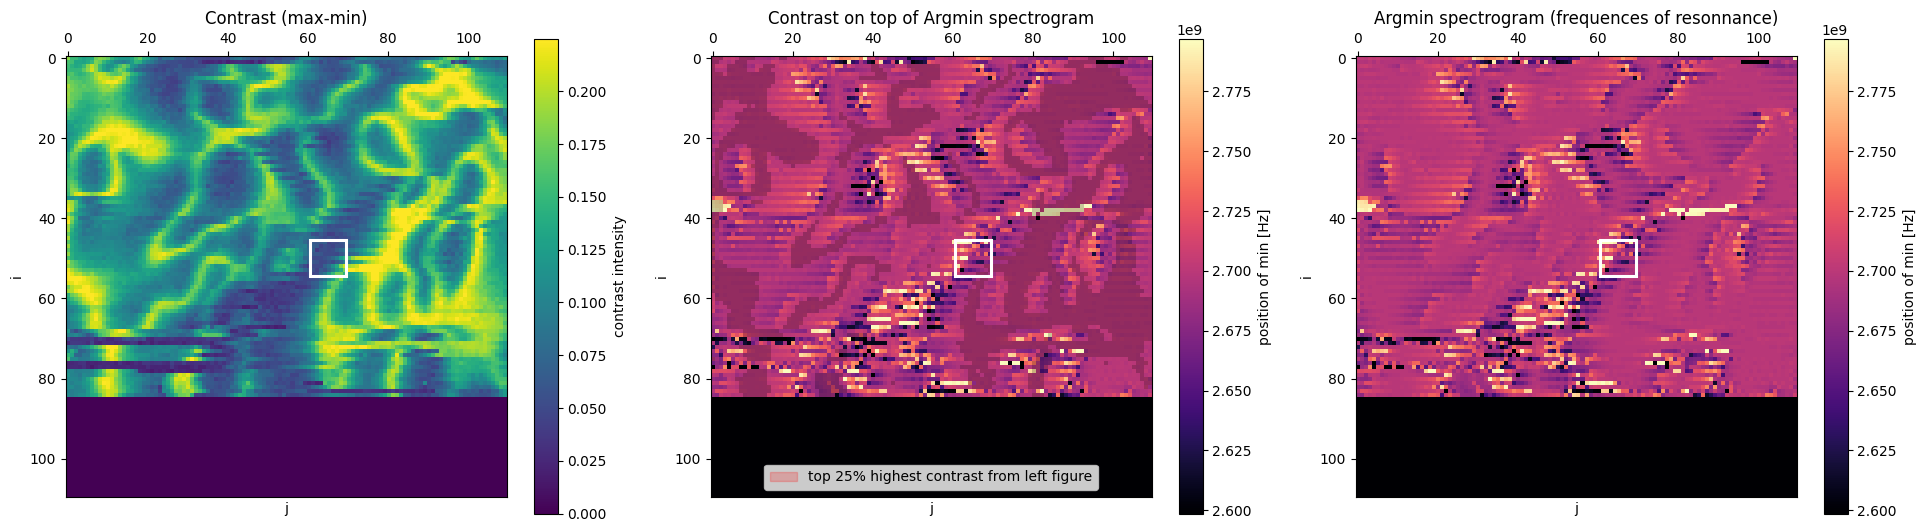

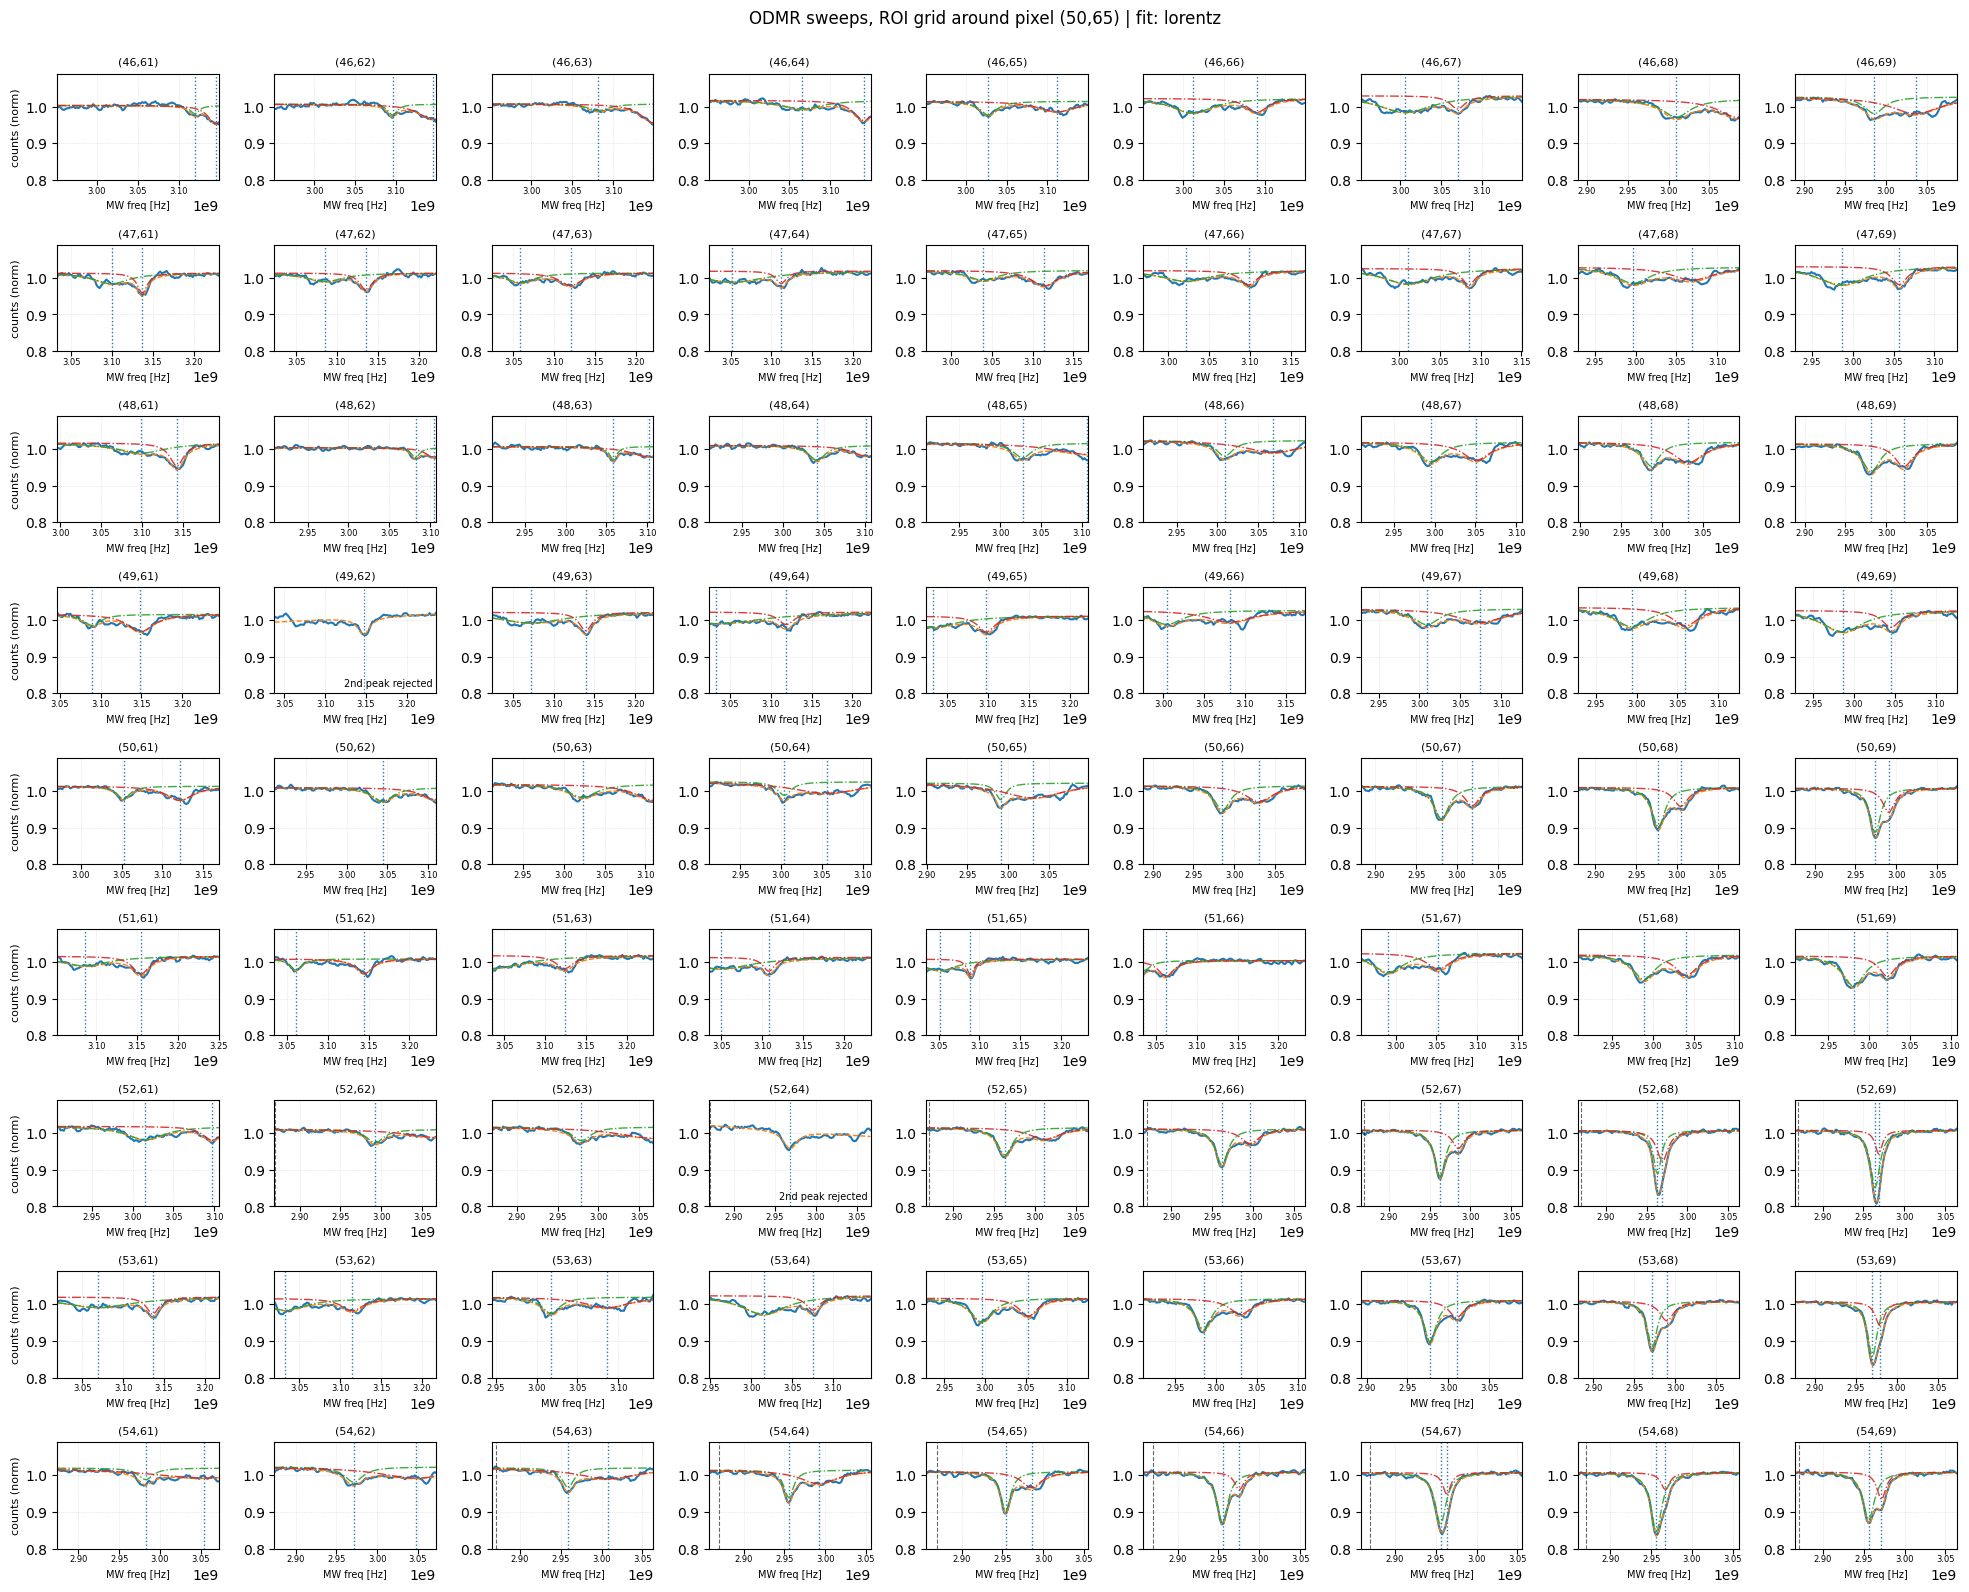

     i   j           xv1           xv2       mode subset
0   46  61  2.594769e+09  2.620234e+09  two_peaks  right
1   46  62  2.594555e+09  2.643998e+09  two_peaks  right
2   46  63  2.590645e+09  2.657983e+09  two_peaks  right
3   46  64  2.598741e+09  2.674920e+09  two_peaks  right
4   46  65  2.628268e+09  2.712447e+09  two_peaks  right
..  ..  ..           ...           ...        ...    ...
76  54  65  2.754238e+09  2.785909e+09  two_peaks  right
77  54  66  2.764494e+09  2.785077e+09  two_peaks  right
78  54  67  2.776475e+09  2.784036e+09  two_peaks  right
79  54  68  2.772692e+09  2.783574e+09  two_peaks  right
80  54  69  2.768456e+09  2.783961e+09  two_peaks  right

[81 rows x 6 columns]


In [11]:
n_i, n_j, n_k = int(df["i"].max() + 1), int(df["j"].max() + 1), int(df["k"].max() + 1)
print(f"dimentions :  {n_i}, {n_j}, {n_k}")

#Avec ces paramètres, on va faire un plot des fits sur le spectrogramme du pixel (50, 56) et sur les half_small=4 pixels adjacents, càd un plot avec (4+1+4)*(4+1+4) subfigures
center_i = 50 #70
center_j = 65  #60 58
half_big = 400
half_small = 4

if half_small<=8:
    SHOW_PLOT = True
else:
    SHOW_PLOT = False


i0_box = center_i - half_small
i1_box = center_i + half_small
j0_box = center_j - half_small
j1_box = center_j + half_small

roi_box = (i0_box, i1_box, j0_box, j1_box)


plot_contrast_argmin(df, NORMALIZE, SMOOTH_WIN,
              center_i, center_j, half=half_big, use_processed=True, grid=False, panel_size=(6.5,5.5),
              roi_box=roi_box,
              #pdf_path="map.pdf",
              )

f=plot_fits_on_spectrograms(df, NORMALIZE, SMOOTH_WIN,
              center_i, center_j, half=half_small, share_axes=True,  # même axe pour toutes les subfigures
              per_panel_x=True,
              mark_two_min=True,                                     # active l’affichage des fits
              fit_model="lorentz",
              initialisation="symmetric",                            #"symmetric", "symmetric_and_map", #"map",
              maponly_=False,
              freq_mode=FREQ_MODE,
              min_curve_amp=0.1, min_peak_amp=0.2, maxcurve=1, min_separation_peak=0.02, show_components=True, legend="none", #diverses conditions sur courbure et amplitudes 
                                                                                                                              #pour éviter les fits étranges/incohérents
              #pdf_path="scan_full_6.pdf",
              #freq_mode="frequency", #"k_linear"                    # pour le debug, pas utile
              #panel_size=(1.2, 1.0),
              D=2.87e9,                                              # fréquence de symétrie (zero field splitting)
              show_plots=SHOW_PLOT,    #False #True
              keep_if_global_min=False,                              # divers autres paramètres pour stabiliser les fits
              freq_à_gauche=True,
              baseline_to_zero=True,
              old_init_sym=True,
              ) #, legend="small", legend_loc="lower right", legend_fontsize=5)


print(f)

### Attention : chaque figure de fit correspond à un pixel de l'image. Sur la figure du dessus avec ``plot_contrast_argmin`` le carré blanc délimite la zone observée. 
Pour faire les fits sur tous les spectrogrammes, il faut donc mettre ``half_small`` avec des grandes valeurs de pixels (afin que le carré blanc couvre toutes les données).  
Pour des grands scans (100*100 pixels ou plus) cela peut prendre jusqu'à 10 min (ou 30 min avec initialisation MAP)

In [12]:
half_small = 80  #mettre arbitrairement grand pour être sur de couvrir toutes les données, généralement les scans font entre 50 et 150 pixels de largeur
SHOW_PLOT=False  #on retire le plot des fits qui prend du temps

f=plot_fits_on_spectrograms(df, NORMALIZE, SMOOTH_WIN,
              center_i, center_j, half=half_small, share_axes=True,
              per_panel_x=True,
              mark_two_min=True,  
              fit_model="lorentz",
              initialisation="symmetric", #"symmetric", "symmetric_and_map", #"map",
              maponly_=False,
              freq_mode=FREQ_MODE,
              min_curve_amp=0.1, min_peak_amp=0.2, maxcurve=1, min_separation_peak=0.02, show_components=True, legend="none",
              D=2.87e9,
              show_plots=SHOW_PLOT, #False #True
              keep_if_global_min=False,
              freq_à_gauche=True,
              baseline_to_zero=True,
              old_init_sym=True,
              )
print("pixel ij, argmin1 et argmin2 des fits lorentziens")
print(f)

pixel ij, argmin1 et argmin2 des fits lorentziens
         i    j           xv1           xv2       mode subset
0        0    0  2.798292e+09  2.805047e+09  two_peaks   left
1        0    1  2.794244e+09  2.802820e+09  two_peaks   left
2        0    2  2.788567e+09  2.800268e+09  two_peaks   left
3        0    3  2.786546e+09  2.799079e+09  two_peaks   left
4        0    4  2.784802e+09  2.795838e+09  two_peaks   left
...    ...  ...           ...           ...        ...    ...
12095  109  105           NaN           NaN        NaN   left
12096  109  106           NaN           NaN        NaN   left
12097  109  107           NaN           NaN        NaN   left
12098  109  108           NaN           NaN        NaN   left
12099  109  109           NaN           NaN        NaN   left

[12100 rows x 6 columns]


## PLOTS

Une fois que les fits sont faits, et que les minimums des fréquences ont été extraits automatiquement, on peut effectuer divers plots.  
The two fitted frequencies are converted to projected field values using
$$
B_{\parallel,1} = \frac{f_{\rm high} - D}{\gamma_{\rm NV}}, \quad
B_{\parallel,2} = \frac{f_{\rm low} - D}{\gamma_{\rm NV}}, \quad
\Delta B_{\parallel} = \frac{f_{\rm high} - f_{\rm low}}{\gamma_{\rm NV}}
$$

c:\Users\herma\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


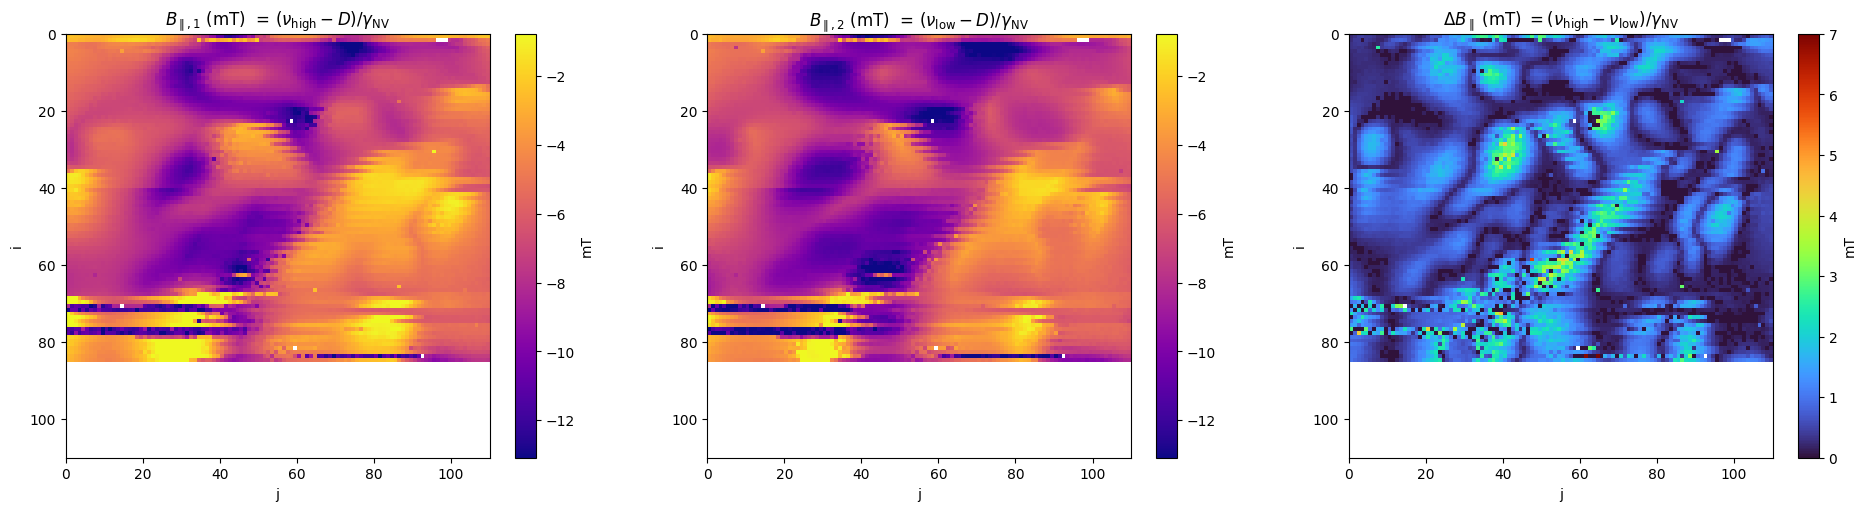

In [13]:
# Calcule B à partir des fréquences
df_B, B1_projectionNV, B2_projectionNV, DeltaB_projectionNV = compute_B_components(
    f, n_i, n_j, clip_negative=False
)

i0, i1 = int(f["i"].min()), int(f["i"].max())
j0, j1 = int(f["j"].min()), int(f["j"].max())
roi = (slice(i0, i1+1), slice(j0, j1+1))

# [x_min, x_max, y_min, y_max] en indices absolus
extent_roi = [j0, j1+1, i0, i1+1]

plot_B1_B2_DeltaB_projectionNV(
    (B1_projectionNV[roi]),
    (B2_projectionNV[roi]),
    DeltaB_projectionNV[roi],
    extent=extent_roi,          
    # roi_box=roi_box,
    #clim1_mT=(0, 18),  #clip pour les colormap subfigure 1 et 2
    clim3_mT=(0, 7),   #clip pour la colormap subfigure 3
)


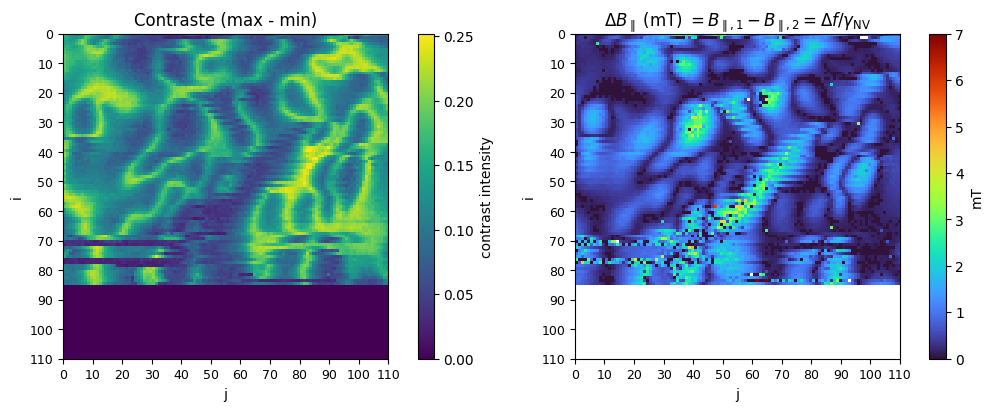

In [14]:
plot_contrast_DeltaB_projectionNV(
    df=df,
    NORMALIZE=NORMALIZE,
    SMOOTH_WIN=SMOOTH_WIN,
    roi=roi,
    Bsplit_T_roi=DeltaB_projectionNV[roi],
    extent_roi=extent_roi,
    use_processed=True,
    cmap_contrast="viridis",
    cmap_split_name="turbo",
    max_ticks=8,
    grid=False,
    figsize=(10,4),
    count_brut=False,
    vmax=7.0,
)

c:\Users\herma\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


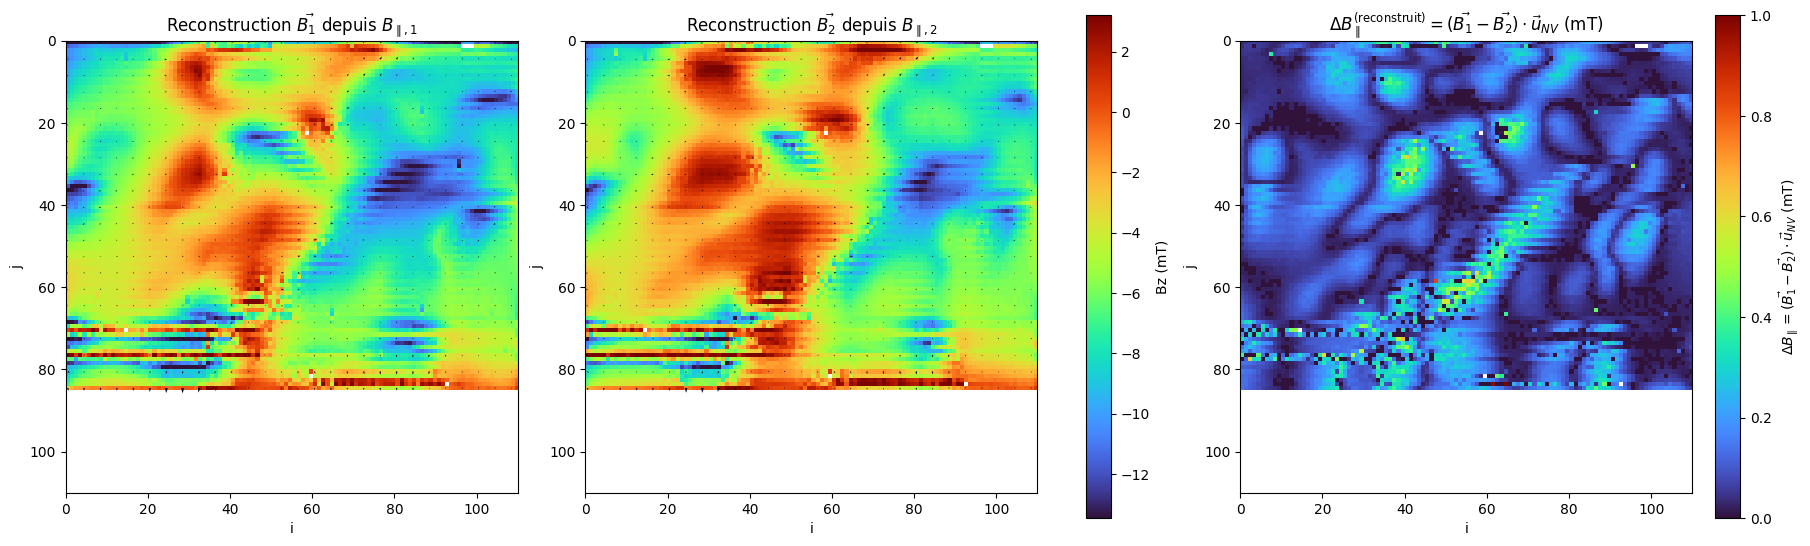

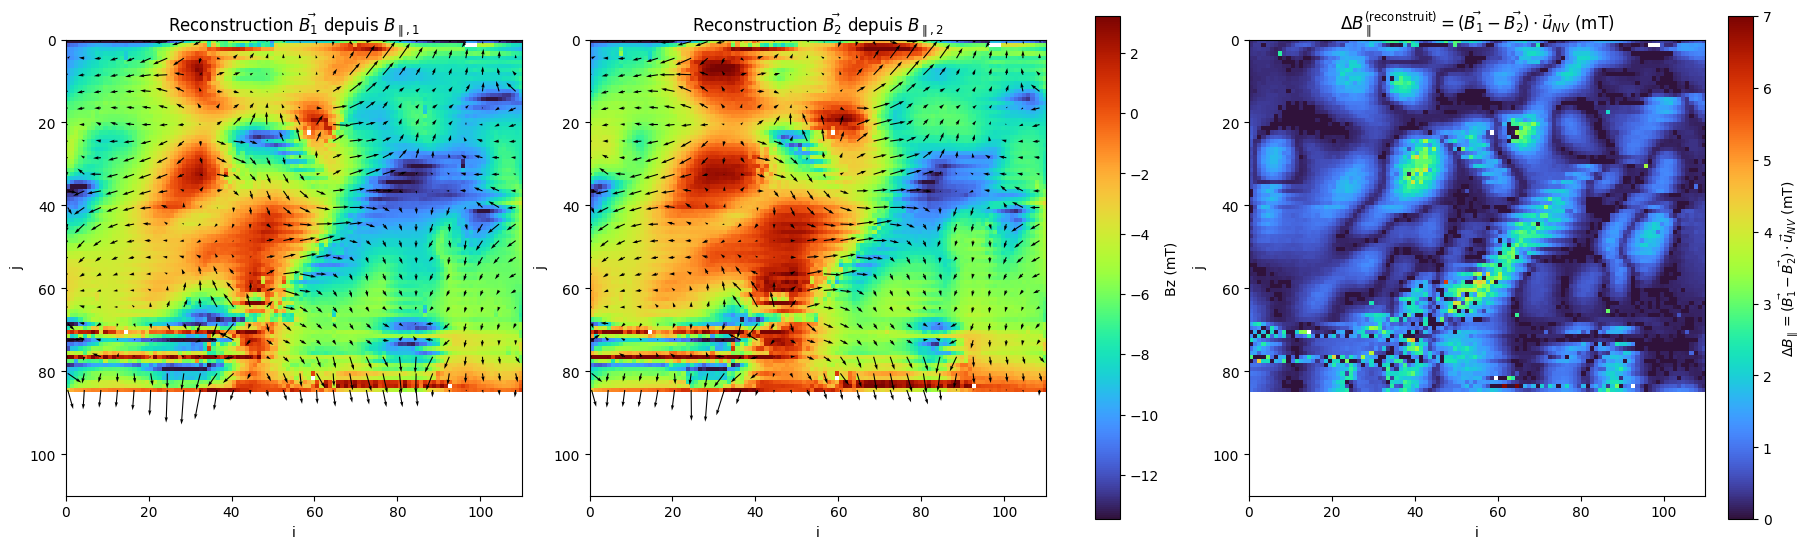

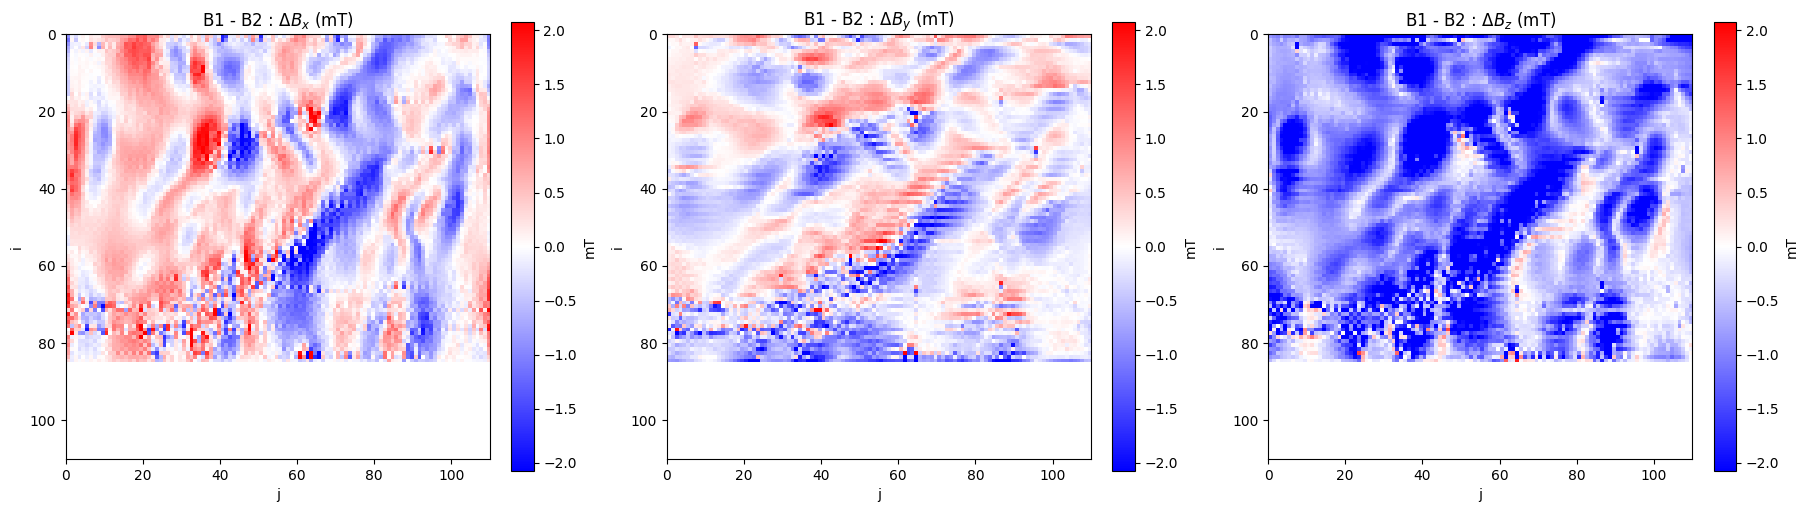

In [15]:
from helpers import reconstruction_B, plot_B_difference

#angle de la pointe NV et autres parametres
theta_deg       = param_exp["vectorMagnetSettings"]["theta"] #125.5
phi_deg         = param_exp["vectorMagnetSettings"]["phi"] #90.0   
z_meas_physical = param_exp["scanHeightControl"]["scanDistance"]  #autour de 1-150 nm, hauteur du scan, 150e-9
B_ext           = param_exp["vectorMagnetSettings"]["field_strength"] * 1e-3 #1-10 * 1e-3  #conversion en T

theta = np.deg2rad(theta_deg)
phi   = np.deg2rad(phi_deg)

nv_axis = np.array([
    np.sin(theta) * np.cos(phi),
    np.sin(theta) * np.sin(phi),
    np.cos(theta),
])


# Reconstruction + quivers
(Bx1, By1, Bz1), (Bx2, By2, Bz2), (BxD, ByD, BzD) = reconstruction_B(
    B1_T=(B1_projectionNV[roi]) + B_ext,
    B2_T=(B2_projectionNV[roi]) + B_ext,
    nv_axis=nv_axis,
    dx=1,
    d_meas=z_meas_physical,
    extent=extent_roi,
    step=4,
    with_norm_2D=True,
    color_mode="Bz",
    dark_bg=False,
    colorbar_whitebg="turbo",
    cmap_name="jet",
    diff_mode="Bpar", #"quiver", "norm", "Bpar"
)
(Bx1, By1, Bz1), (Bx2, By2, Bz2), (BxD, ByD, BzD) = reconstruction_B(
    B1_T=(B1_projectionNV[roi]) + B_ext, #met en T
    B2_T=(B2_projectionNV[roi]) + B_ext,
    nv_axis=np.asarray(nv_axis, float),
    dx=1,
    d_meas=z_meas_physical,
    extent=extent_roi,
    step=4,
    s=0.16,
    with_norm_2D=True,
    color_mode="Bz",
    dark_bg=False,
    cmap_name="jet",
    diff_mode="Bpar",
    clim3_mT=(0,7),
    colorbar_whitebg="turbo",
    #Size_um=Size_um,
    #scalebar=True,
)

# Cartes d'erreur B1 - B2 (Bx, By, Bz)
plot_B_difference(
    Bx1, By1, Bz1,
    Bx2, By2, Bz2,
    extent=extent_roi,
)


## More Fits...

['2025-12-08-14-55-16']
z_meas_physical: 1.3e-07
2025-12-08-14-55-16 --- dims: 80, 100, 100

CARRE red


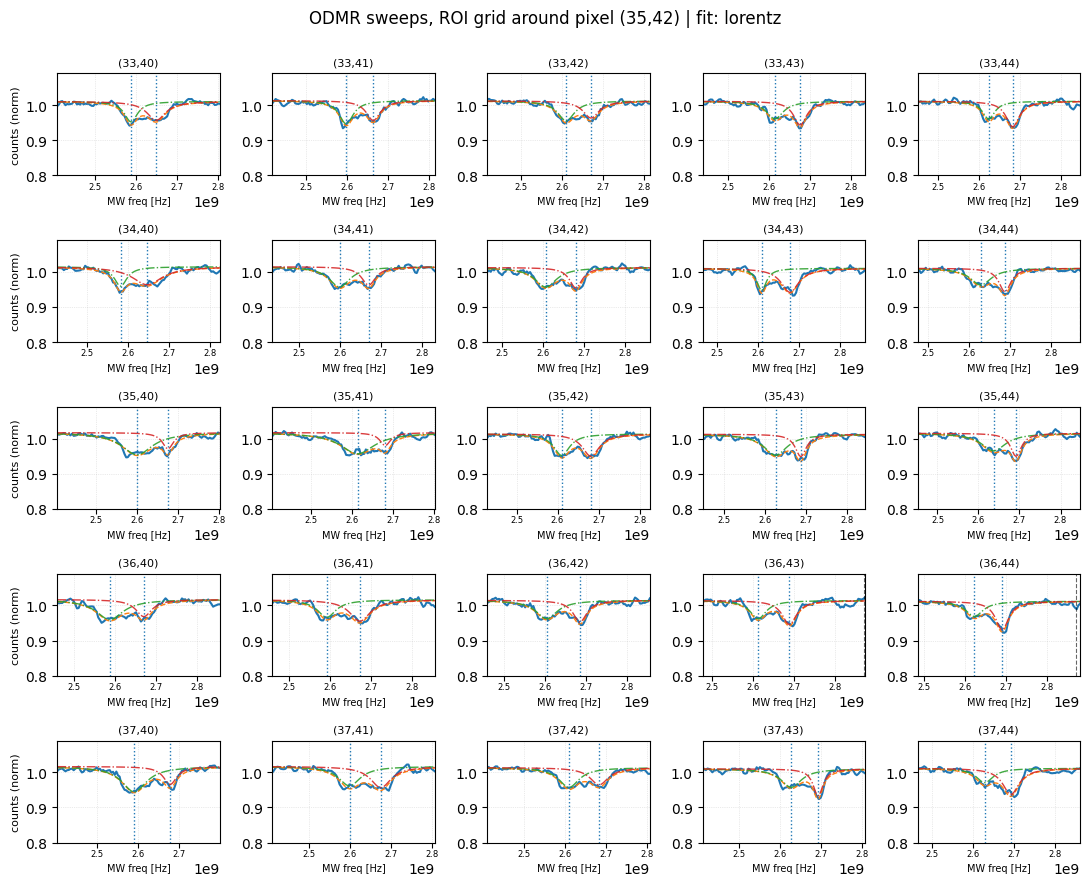


CARRE lime


<Figure size 640x480 with 0 Axes>

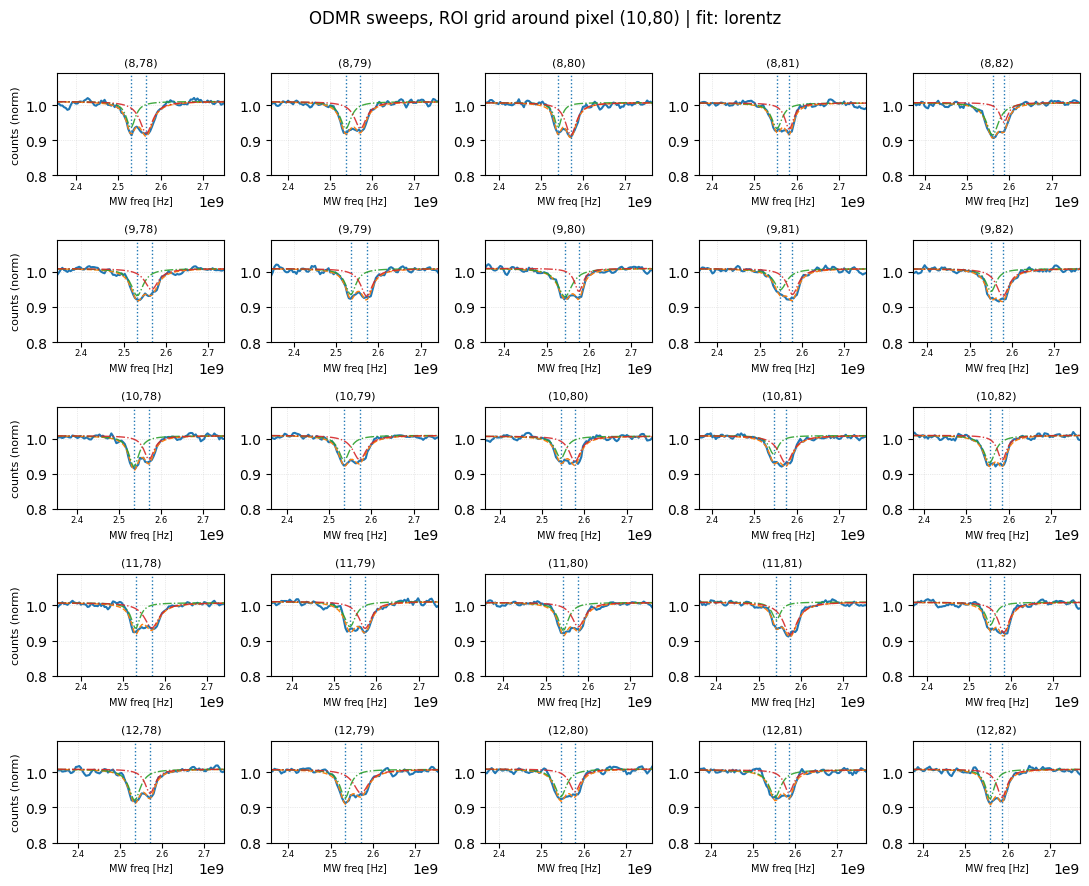


CARRE blue


<Figure size 640x480 with 0 Axes>

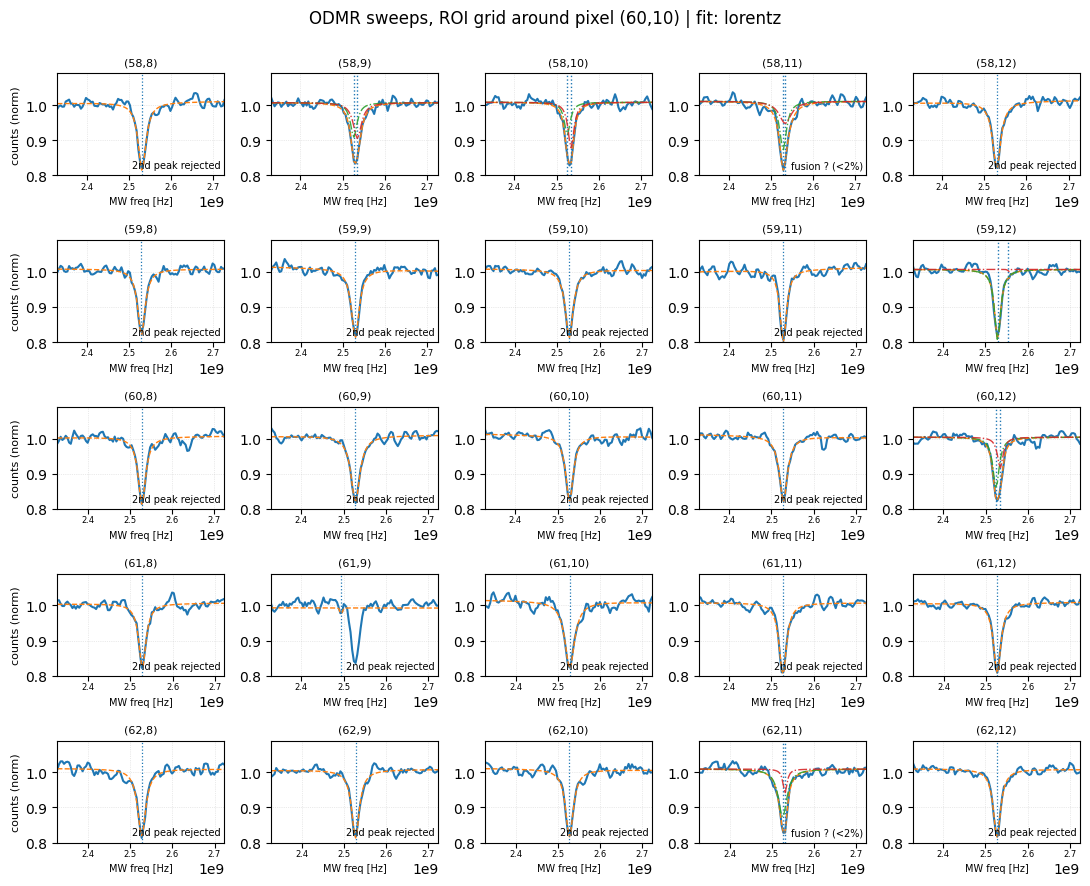


CARRE yellow


<Figure size 640x480 with 0 Axes>

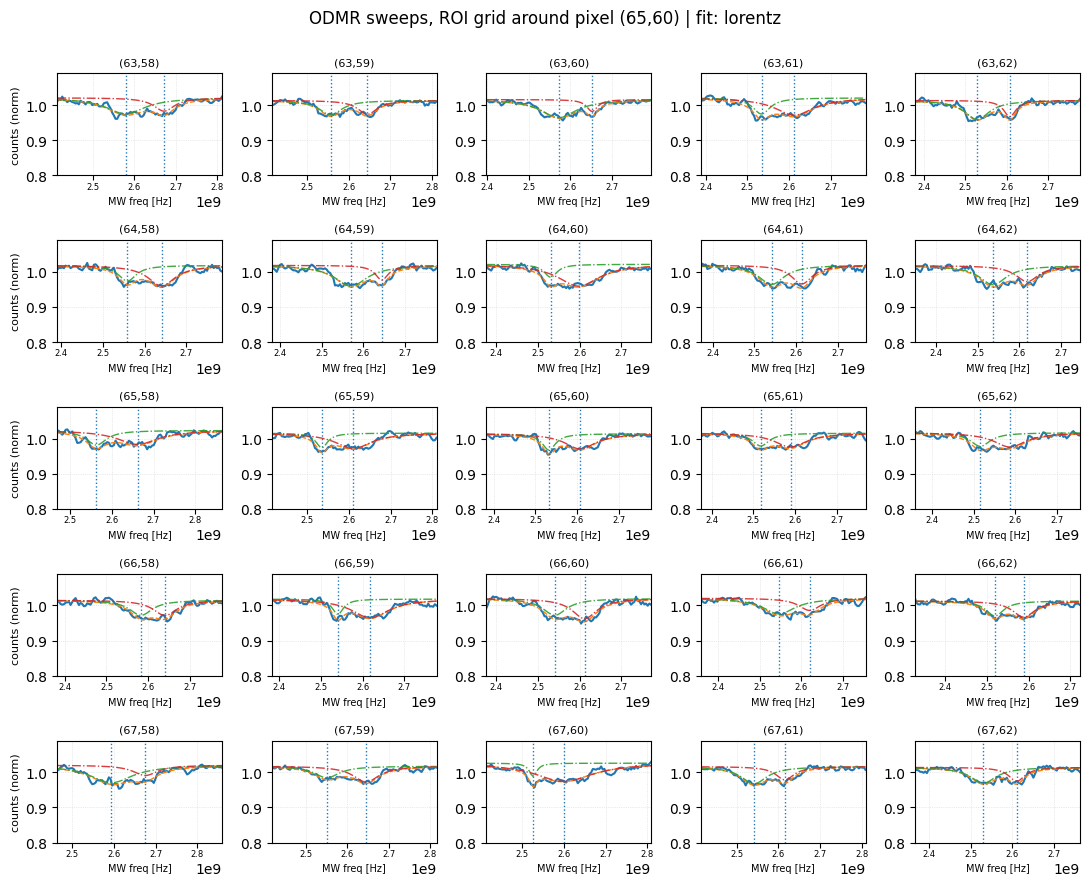

<Figure size 640x480 with 0 Axes>

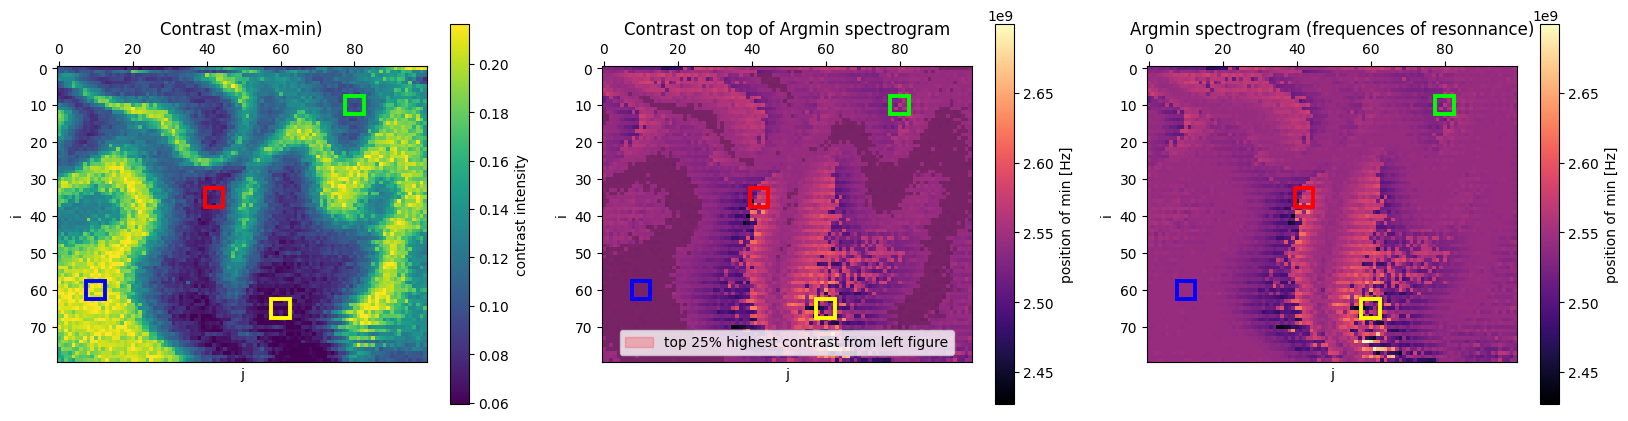

c:\Users\herma\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


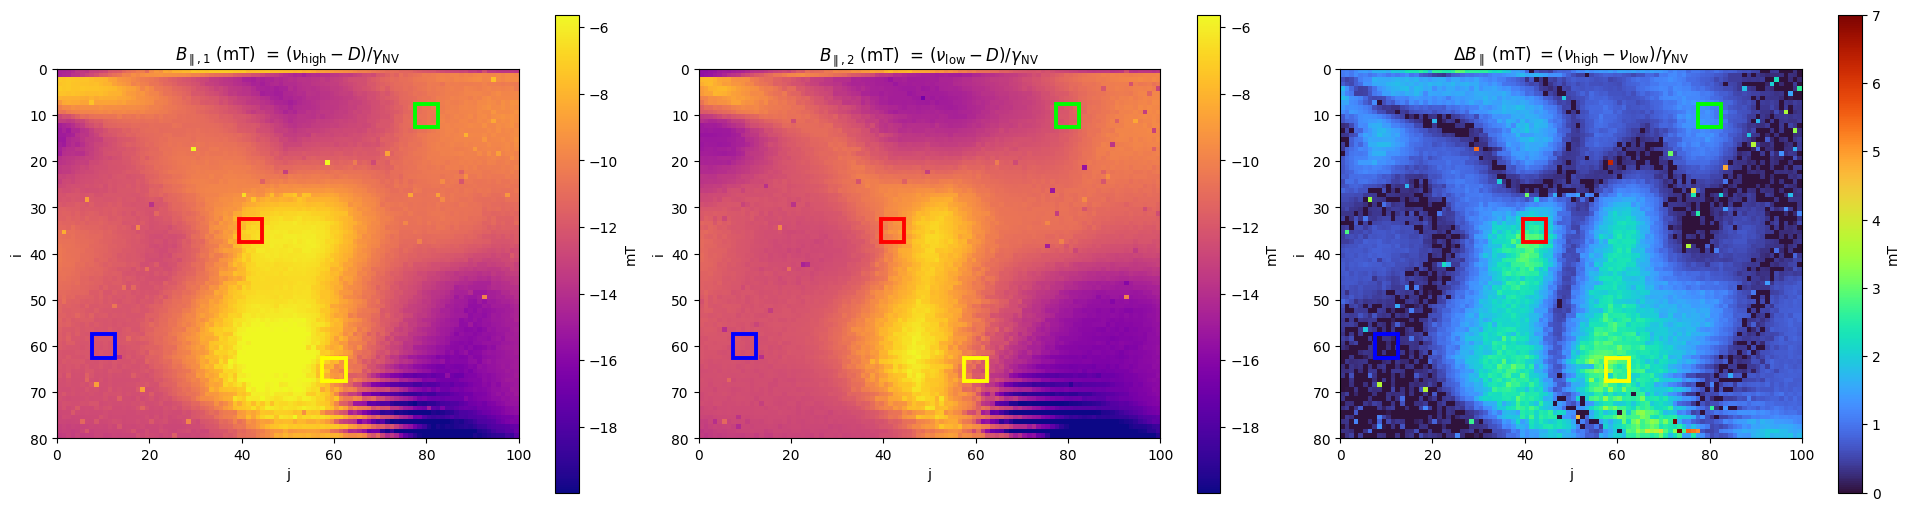

<Figure size 640x480 with 0 Axes>

In [16]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

all_B1_maps = []
all_B2_maps = []
all_z_meas  = []

plot_directory = Path(r"C:\Users\herma\OneDrive\Bureau\Etudes EPFL\PDM\plots_finaux")

dates2=["2025-12-08-14-55-16"]  #all_dates[39:43]   #etude hysterese
print(dates2)
for date in dates2:
    base = data_directory / f"{date}-odmr_hardware" / "seq0" / "eval"
    df_path = base / "odmr.txt"
    meta_path = data_directory / f"{date}-odmr_hardware" / "imageMeta.json"

    with open(meta_path, "r") as f:
        meta = json.load(f)

    z_meas_physical = meta["scanHeightControl"]["scanDistance"]
    print("z_meas_physical:", z_meas_physical)

    df = load_df1(df_path, DOWNCAST_INT)

    if date == "2025-11-16-23-41-29":
        band_folder = data_directory / "2025-11-17-18-36-10-odmr_hardware" / "seq0" / "eval"
        band_file = band_folder / "odmr.txt"
        df_band = load_df1(band_file, DOWNCAST_INT=True)
        df = concatener_data_df1(df, df_band, infos=False)

    n_i = int(df["i"].max() + 1)
    n_j = int(df["j"].max() + 1)
    n_k = int(df["k"].max() + 1)
    print(f"{date} --- dims: {n_i}, {n_j}, {n_k}")

    center_i, center_j = 35, 35
    half_small = 2
    half_big   = 100
    PLOT = (half_small <= 8)
    init = "symmetric"

    # ---- 4 ROIs colorés ----
    # offset = 10  
    # roi_defs = [
    #     {"name": "ROUGE", "color": "red",    "center": (center_i - offset, center_j - offset)},
    #     {"name": "VERT",  "color": "lime",  "center": (center_i - offset, center_j + offset)},
    #     {"name": "BLEU",  "color": "blue",   "center": (center_i + offset, center_j - offset)},
    #     {"name": "JAUNE", "color": "yellow", "center": (center_i + offset, center_j + offset)},
    # ]
    roi_defs = [
        {"name": "ROUGE", "color": "red",    "center": (35, 42)},
        {"name": "VERT",  "color": "lime",  "center": (10, 80)},
        {"name": "BLEU",  "color": "blue",   "center": (60, 10)},
        {"name": "JAUNE", "color": "yellow", "center": (65, 60)},
    ]

    def roi_box_from_center(ci, cj, half):
        return (ci - half, ci + half, cj - half, cj + half)

    roi_boxes = []
    for d in roi_defs:
        ci, cj = d["center"]
        d["roi_box"] = roi_box_from_center(ci, cj, half_small)
        roi_boxes.append({"roi_box": d["roi_box"], "color": d["color"], "lw": 2.8, "ls": "-"})

    # =========================
    # 1) 4x petits fits (un par ROI)
    # =========================
    for d in roi_defs:
        ci, cj = d["center"]
        if PLOT:
            print(f"\nCARRE {d['color']}")
            f_small = plot_fits_on_spectrograms(
                df, NORMALIZE, SMOOTH_WIN,
                ci, cj, half=half_small, share_axes=True,
                mark_two_min=True,
                per_panel_x=True,
                fit_model="lorentz",
                initialisation=init,
                maponly_=False,

                min_curve_amp=0.1, min_peak_amp=0.2, maxcurve=1, min_separation_peak=0.02,
                show_components=True,
                legend="none",
                freq_mode="frequency",

                D=2.87e9,
                show_plots=True,
                keep_if_global_min=False,
                freq_à_gauche=True,
                baseline_to_zero=True,
            )
            try:
                plt.gcf().suptitle(f"{date} - ROI {d['name']} - center=({ci},{cj})", color=d["color"])
            except Exception:
                pass

    # =========================
    # 2) Grands plots + overlay des 4 carrés (directement via roi_boxes=)
    # =========================

    plot_contrast_argmin(
        df, NORMALIZE, SMOOTH_WIN,
        center_i, center_j, half=half_big,
        use_processed=True,
        grid=False,
        panel_size=(5.5, 4.5),
        roi_boxes=roi_boxes,   # <-- les 4 carrés colorés
    )

    
    f_big = plot_fits_on_spectrograms(
        df, NORMALIZE, SMOOTH_WIN,
        center_i, center_j, half=half_big, share_axes=True,
        per_panel_x=True,
        mark_two_min=True,
        fit_model="lorentz",
        initialisation=init,
        maponly_=False,
        freq_mode=FREQ_MODE,
        min_curve_amp=0.1, min_peak_amp=0.2, maxcurve=1, min_separation_peak=0.02,
        show_components=True,
        legend="none",
        D=2.87e9,
        show_plots=False,
        keep_if_global_min=False,
        freq_à_gauche=True,
        baseline_to_zero=True,
        old_init_sym=False,
    )

    i0, i1 = int(f_big["i"].min()), int(f_big["i"].max())
    j0, j1 = int(f_big["j"].min()), int(f_big["j"].max())
    roi = (slice(i0, i1 + 1), slice(j0, j1 + 1))
    extent_roi = [j0, j1 + 1, i0, i1 + 1]

    df_B, B1_projectionNV, B2_projectionNV, DeltaB_projectionNV = compute_B_components(f_big, n_i, n_j, clip_negative=False)

    # FIG triptych (avec overlay)
    plot_B1_B2_DeltaB_projectionNV(
        B1_projectionNV[roi], B2_projectionNV[roi], DeltaB_projectionNV[roi],
        extent=extent_roi,
        roi_boxes=roi_boxes,  # <-- 4 carrés colorés
        clim3_mT=(0, 7),
    )



    fig = plt.gcf()
    #for ax in fig.axes:
    #    if len(getattr(ax, "images", [])) > 0:   # évite de dessiner dans les axes des colorbars
    #        _add_roi_boxes(ax, roi_boxes=roi_boxes, default_lw=2.8)
    plt.show()
